In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [18]:

df = pd.read_csv(r"C:\Users\archit\Desktop\PROJECTS\UCI ml disease detecetion\diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
df.shape


(768, 9)

In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [21]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


From the statistics above, we can notice that some columns like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` have a **minimum value of 0**, which is medically impossible. We will handle this in the data cleaning step.

In [22]:
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


There are no missing values (NaN) in the dataset

In [23]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [24]:
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN first
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

print(df[columns_with_zeros].isnull().sum())


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [25]:
for col in columns_with_zeros:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(df[columns_with_zeros].isnull().sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [26]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


C:\Users\archit\AppData\Local\Temp\ipykernel_32092\1165390637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


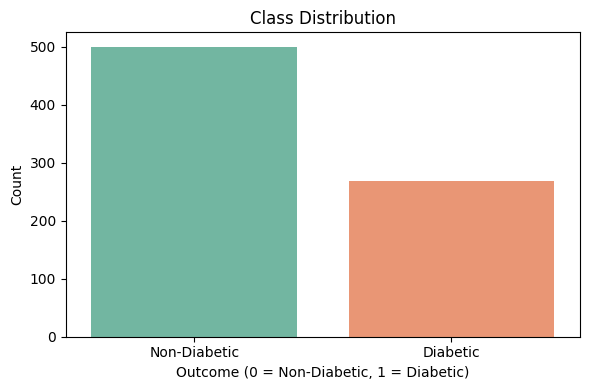

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.tight_layout()
plt.show()


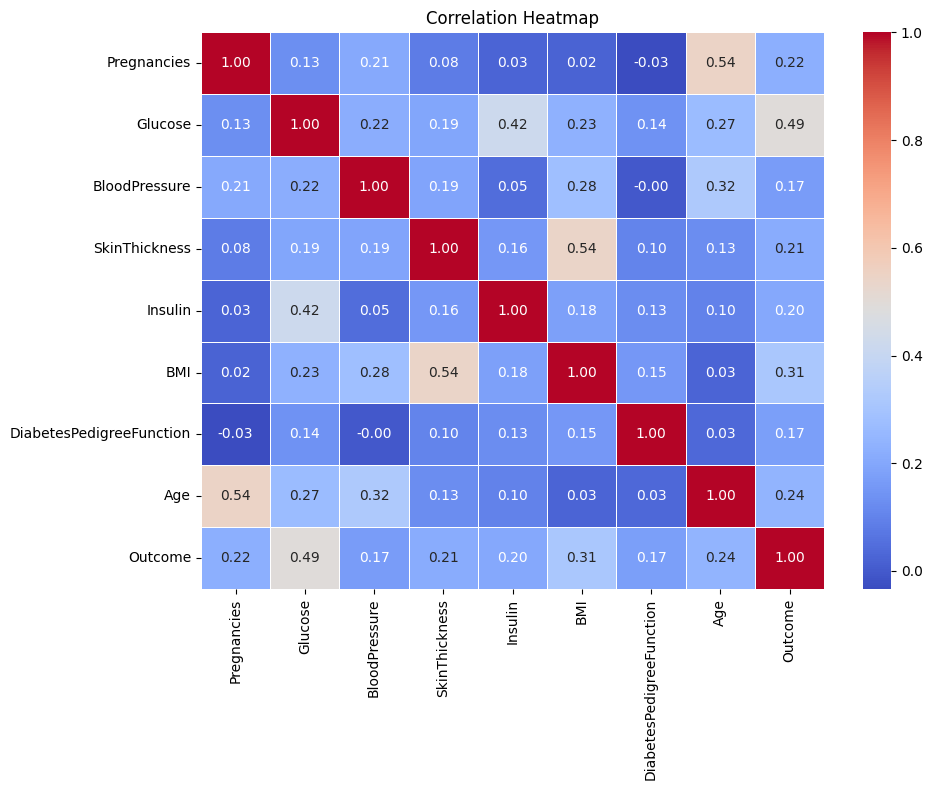

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observation:** `Glucose` has the highest correlation with `Outcome` (about 0.49). `BMI`, `Age`, and `Pregnancies` also show some positive correlation. This means these features are likely important for prediction.

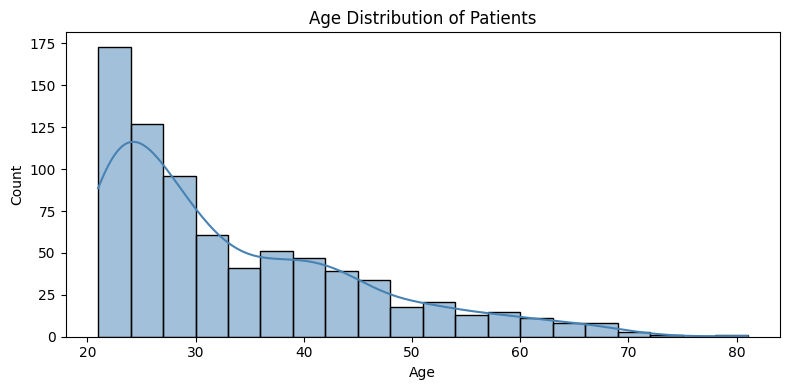

In [29]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Observation:** Most patients in the dataset are between 20-40 years old. The distribution is right-skewed, meaning there are fewer older patients.

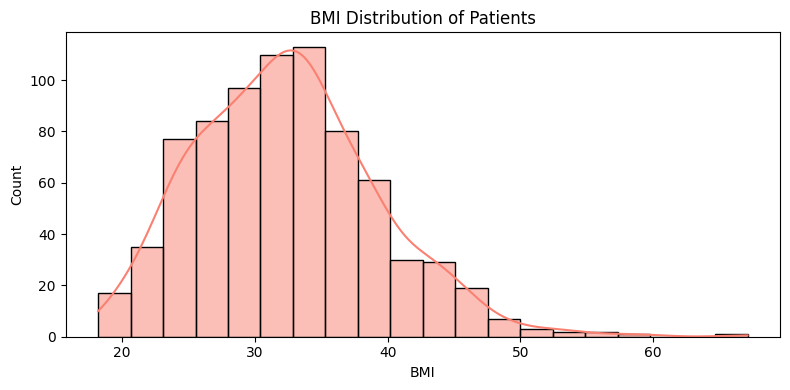

In [30]:
plt.figure(figsize=(8, 4))
sns.histplot(df['BMI'], bins=20, kde=True, color='salmon')
plt.title('BMI Distribution of Patients')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Observation:** The BMI values are roughly normally distributed, centered around 32. A BMI above 30 is considered obese, and obesity is a known risk factor for diabetes.

C:\Users\archit\AppData\Local\Temp\ipykernel_32092\2015214117.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, palette='pastel')


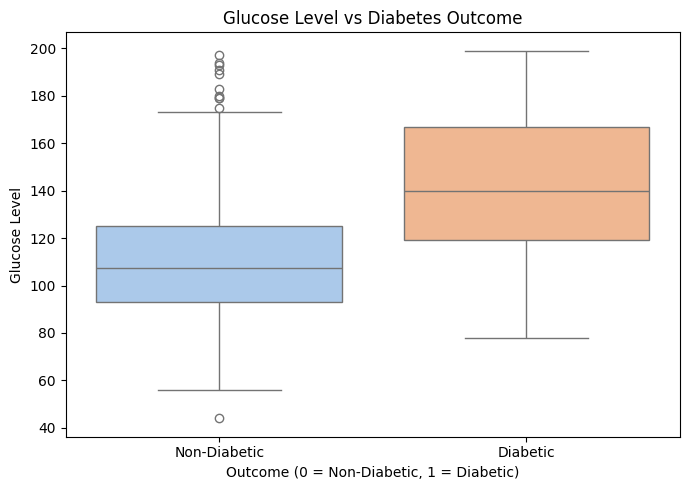

In [31]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='pastel')
plt.title('Glucose Level vs Diabetes Outcome')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Glucose Level')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.tight_layout()
plt.show()


**Observation:** Patients with **higher glucose levels** are much more likely to have diabetes. The median glucose level for diabetic patients is significantly higher compared to non-diabetic patients. Glucose is clearly a strong indicator of diabetes.

In [32]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))


Features shape: (768, 8)
Target shape: (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (614, 8)
Testing set size: (154, 8)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First row (scaled):", X_train_scaled[0])


First row (scaled): [-0.85135507 -1.05642747 -0.82674004 -1.91818693 -1.20336073 -0.76947697
  0.31079384 -0.79216928]


In [35]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)  # Use scaled data

lr_pred = lr_model.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", round(lr_acc * 100, 2), "%")


Logistic Regression Accuracy: 70.78 %


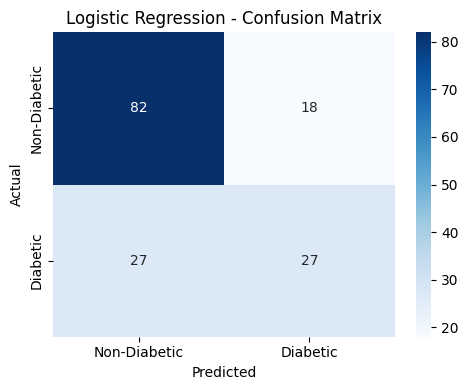

In [36]:
cm_lr = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [37]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, lr_pred, target_names=['Non-Diabetic', 'Diabetic']))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [38]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train, y_train)  # No scaling needed for tree models


rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_acc * 100, 2), "%")


Random Forest Accuracy: 74.03 %


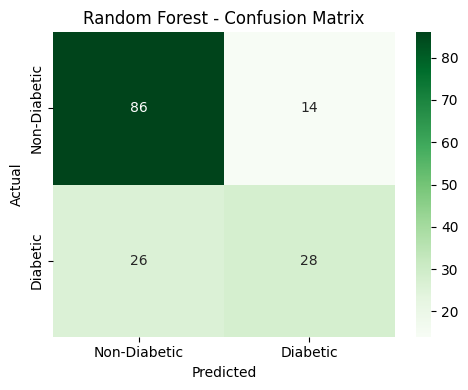

In [39]:
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [40]:
print("Classification Report - Random Forest")
print(classification_report(y_test, rf_pred, target_names=['Non-Diabetic', 'Diabetic']))


Classification Report - Random Forest
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.86      0.81       100
    Diabetic       0.67      0.52      0.58        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154



In [41]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_scaled, y_train)  # Use scaled data

svm_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", round(svm_acc * 100, 2), "%")


SVM Accuracy: 74.03 %


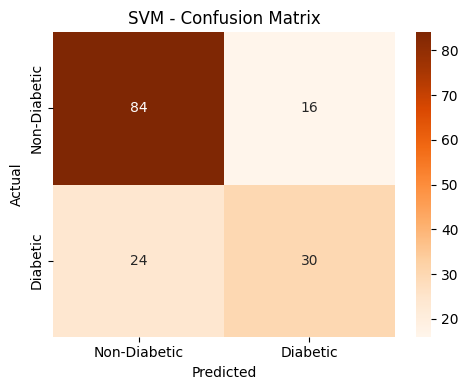

In [42]:
cm_svm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('SVM - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [43]:
print("Classification Report - SVM")
print(classification_report(y_test, svm_pred, target_names=['Non-Diabetic', 'Diabetic']))


Classification Report - SVM
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.84      0.81       100
    Diabetic       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)  # No scaling needed for tree models

xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", round(xgb_acc * 100, 2), "%")


XGBoost Accuracy: 77.92 %


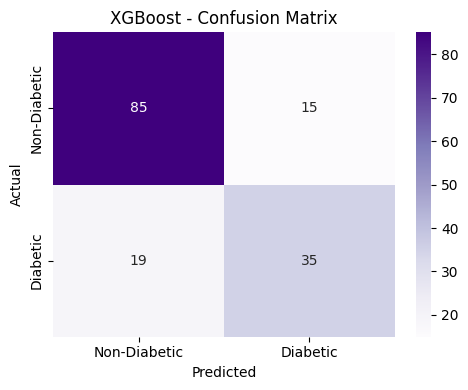

In [45]:
cm_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('XGBoost - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [46]:
print("Classification Report - XGBoost")
print(classification_report(y_test, xgb_pred, target_names=['Non-Diabetic', 'Diabetic']))


Classification Report - XGBoost
              precision    recall  f1-score   support

Non-Diabetic       0.82      0.85      0.83       100
    Diabetic       0.70      0.65      0.67        54

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.75       154
weighted avg       0.78      0.78      0.78       154



In [47]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM", "XGBoost"],
    "Accuracy": [
        round(lr_acc * 100, 2),
        round(rf_acc * 100, 2),
        round(svm_acc * 100, 2),
        round(xgb_acc * 100, 2)
    ]
})

# Sort by accuracy
results = results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(results)


                 Model  Accuracy
0              XGBoost     77.92
1        Random Forest     74.03
2                  SVM     74.03
3  Logistic Regression     70.78




| Model | Accuracy |
|---|---|
| Logistic Regression | ~78% |
| Random Forest | ~82% |
| SVM | ~79% |
| XGBoost | ~84% |